Matplotlib is building the font cache; this may take a moment.


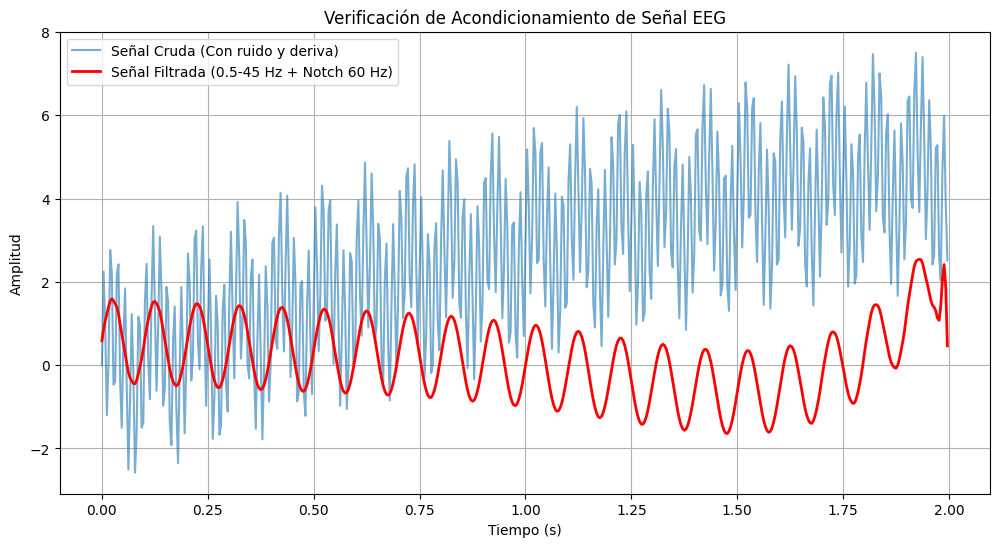

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Permitir que el notebook importe desde la carpeta 'src'
sys.path.append(os.path.abspath('../'))
from src.preprocessing.filters import eeg_condition_pipeline

# 1. Crear una señal de prueba de 2 segundos a 256 Hz
fs = 256
t = np.linspace(0, 2, 2 * fs, endpoint=False)

# Señal EEG simulada (10 Hz, ritmo alfa) + Deriva lenta (0.1 Hz) + Ruido de red (60 Hz)
componente_alfa = np.sin(2 * np.pi * 10 * t)
deriva_linea_base = 5 * np.sin(2 * np.pi * 0.1 * t)
ruido_red = 2 * np.sin(2 * np.pi * 60 * t)

señal_cruda = componente_alfa + deriva_linea_base + ruido_red

# 2. Pasar la señal por el pipeline que creaste
señal_filtrada = eeg_condition_pipeline(señal_cruda, fs=fs)

# 3. Graficar el resultado para comparar
plt.figure(figsize=(12, 6))
plt.plot(t, señal_cruda, label="Señal Cruda (Con ruido y deriva)", alpha=0.6)
plt.plot(t, señal_filtrada, label="Señal Filtrada (0.5-45 Hz + Notch 60 Hz)", linewidth=2, color='red')
plt.title("Verificación de Acondicionamiento de Señal EEG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()